<a href="https://colab.research.google.com/github/mayura-andrew/ml-experiments/blob/main/Linear_Regression_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("w1_student_scores-220925-152435.csv")

df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [2]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1gzqMt4RzDwjuRUq07391ceyhwpk_spIkveW88955BFI/edit#gid=0


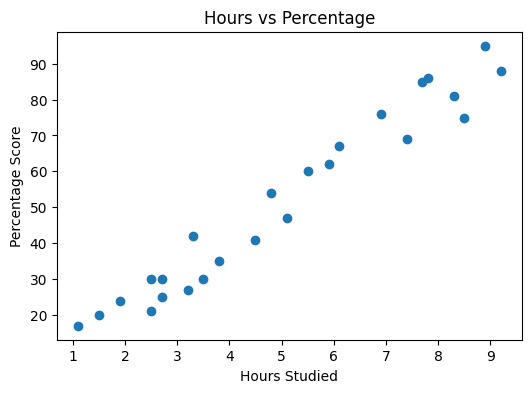

In [3]:
from matplotlib import pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(df['Hours'], df['Scores'])
plt.title('Hours vs Percentage')
plt.xlabel('Hours Studied')
plt.ylabel('Percentage Score')
plt.show()


# Find Coeffients

##Calculate the mena of input and output

In [4]:
xmean = np.mean(df['Hours'])
ymean = np.mean(df['Scores'])

print(xmean)
print(ymean)

5.012
51.48


## calculate the terms needed for the numator and denominator of beta

In [5]:
df['xycov'] = (df['Hours'] - xmean) * (df['Scores'] - ymean)
df['xvar'] = (df['Hours'] - xmean)**2

## Calculate the coeffients

In [6]:
slope = df['xycov'].sum() / df['xvar'].sum()
intercept = ymean - (slope * xmean)
print(f"Slope: {slope}")
print(f"intercept: {intercept}")

Slope: 9.775803390787473
intercept: 2.4836734053731817


##  Making Prediction

In [7]:
intercept + slope*7

np.float64(70.9142971408855)

In [9]:
Scores_predicted = intercept + slope * df['Hours']

## Compute the score of a student who studies for 7 hours

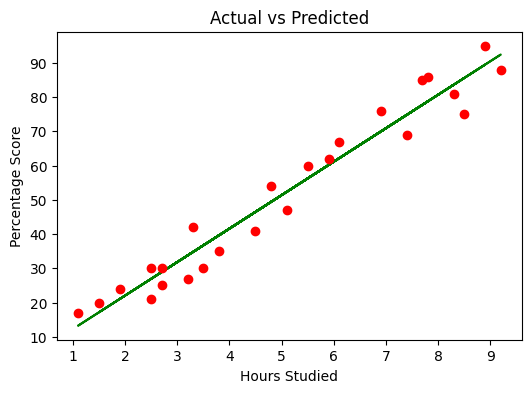

In [13]:
plt.figure(figsize=(6,4))
plt.plot(df['Hours'], Scores_predicted, color='green')
plt.plot(df['Hours'], df['Scores'], 'ro')
plt.title('Actual vs Predicted')
plt.xlabel('Hours Studied')
plt.ylabel('Percentage Score')
plt.show()


### 1. Data Loading and Initial Inspection

- **Cell `9Vn9SYzvseje`**: This cell loads the `w1_student_scores-220925-152435.csv` file into a pandas DataFrame named `df`. It then displays the first few rows of the DataFrame using `df.head()` to give a quick overview of the data, which contains 'Hours' studied and corresponding 'Scores'.

### 2. Data Visualization

- **Cell `3nRCMdFBcI7Z`**: This cell generates a scatter plot to visualize the relationship between 'Hours' studied and 'Scores'. The plot helps in understanding if there's a linear trend between the two variables, which is a prerequisite for simple linear regression.

### 3. Calculating Means

- **Cell `WLZni7uOc9F5`**: To calculate the coefficients (slope and intercept) for the linear regression line, we first need the mean of both the independent variable ('Hours') and the dependent variable ('Scores'). This cell computes `xmean` (mean of 'Hours') and `ymean` (mean of 'Scores').

### 4. Calculating Terms for Coefficients

- **Cell `v7PRc_6bdSvj`**: This cell calculates two intermediate terms crucial for the simple linear regression formulas:
  - `xycov`: The product of the deviations of each 'Hours' value from its mean and each 'Scores' value from its mean. This term is used in the numerator for calculating the slope.
  - `xvar`: The squared deviation of each 'Hours' value from its mean. This term is used in the denominator for calculating the slope.

### 5. Calculating Slope and Intercept

- **Cell `PUlfw6oPd_yL`**: With the `xycov` and `xvar` terms calculated, this cell proceeds to compute the `slope` and `intercept` of the regression line. The formulas used are:
  - `slope = sum(xycov) / sum(xvar)`
  - `intercept = ymean - (slope * xmean)`
  These are the core coefficients of the linear model, allowing us to predict scores based on hours studied.

### 6. Making Predictions

- **Cell `4XPX_qgNer5w`**: This cell demonstrates how to use the calculated `intercept` and `slope` to make a prediction for a specific input. Here, it predicts the score for a student who studies for 7 hours using the equation: `Score = intercept + slope * Hours`.
- **Cell `Dahez5uoe_Hn`**: This cell extends the prediction to all the 'Hours' values present in the original DataFrame, storing the predicted scores in a new Series called `Scores_predicted`.

### 7. Visualizing Actual vs. Predicted Scores

- **Cell `nbn7tfQAfHue`**: Finally, this cell generates another plot to compare the actual 'Scores' with the `Scores_predicted`. The scatter plot (`'ro'`) shows the actual data points, and the line plot (`color='green'`) represents the linear regression line, illustrating how well the model fits the data.

# Multiple Linear Regression

In [14]:
df = pd.read_csv("w1_petrol_consumption-220925-152435.csv")

In [15]:
df.head(5)

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [16]:
df.shape

(48, 5)

In [17]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Petrol_tax,48.0,7.67,0.95,5.00,7.00,7.50,8.12,10.00
Average_income,48.0,4241.83,573.62,3063.00,3739.00,4298.00,4578.75,5342.00
Paved_Highways,48.0,5565.42,3491.51,431.00,3110.25,4735.50,7156.00,17782.00
Population_Driver_licence(%),48.0,0.57,0.06,0.45,0.53,0.56,0.60,0.72
Petrol_Consumption,48.0,576.77,111.89,344.00,509.50,568.50,632.75,968.00


Text(0, 0.5, 'Petrol Consumption')

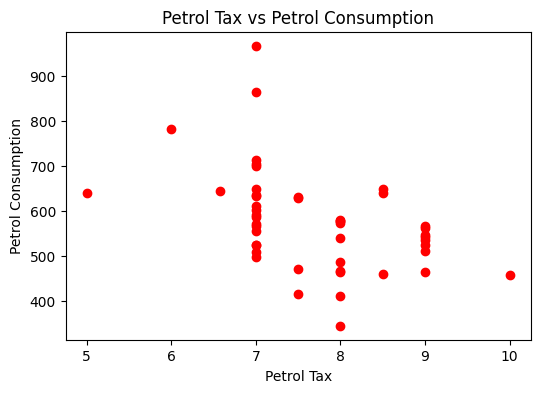

In [18]:
plt.figure(figsize=(6,4))
plt.plot(df['Petrol_tax'], df['Petrol_Consumption'], 'ro')
plt.title('Petrol Tax vs Petrol Consumption')
plt.xlabel('Petrol Tax')
plt.ylabel('Petrol Consumption')

In [19]:
Y = df['Petrol_Consumption']
X = df[['Average_income', 'Paved_Highways', 'Population_Driver_licence(%)', 'Petrol_tax']]

In [20]:
from sklearn.model_selection import train_test_split

X_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [22]:
regressor.intercept_

np.float64(361.45087906668397)

In [23]:
regressor.coef_

array([-5.65355145e-02, -4.38217137e-03,  1.34686930e+03, -3.69937459e+01])

In [26]:
y_pred = regressor.predict(x_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

    Actual   Predicted
27     631  606.692665
40     587  673.779442
26     577  584.991490
43     591  563.536910
24     460  519.058672
37     704  643.461003
12     525  572.897614
19     640  687.077036
4      410  547.609366
25     566  530.037630


# Evaluating the model

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

print(f"MAE: {MAE}")
print(f"MSE: {MSE}")
print(f"RMSE: {RMSE}")

MAE: 53.46854128290797
MSE: 4083.2558717442635
RMSE: 63.9003589328281


In [28]:
regressor.score(x_test, y_test)

0.39136640014305457

In [29]:
regressor.score(X_train, y_train)

0.7068781342155135